In [1]:
import pickle
import openeo
import xarray as xr

In [2]:
with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)

In [3]:
c = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [ ]:
datacube = c.load_collection(
    "SENTINEL2_L2A",
    temporal_extent=[p["start"], p["end"]],
    bands=["B03", "B11", "SCL"],
    max_cloud_cover=80,
)
datacube = datacube.filter_bbox(p["box_3035"], crs=3035)
datacube = datacube.resample_spatial(resolution=10, projection=3035)

In [ ]:
datacube.download("openeo.zarr")

OpenEoApiError: [500] Internal: Server error: java.nio.file.FileSystemException: /tmp/openeo-pydrvr-qsn_7z_b.save_result.zarr/B03: Not a directory (ref: r-2606160851024a6d9089da0e4d9bde74)

In [ ]:
datacube.download("openeo.nc")

In [19]:
dataset = xr.open_dataset("openeo2.nc")
dataset

<xarray.Dataset> Size: 72MB
Dimensions:  (t: 6, x: 1000, y: 1000)
Coordinates:
  * t        (t) datetime64[ns] 48B 2022-01-08 2022-01-10 ... 2022-01-30
  * x        (x) float64 8kB 4.65e+06 4.65e+06 4.65e+06 ... 4.66e+06 4.66e+06
  * y        (y) float64 8kB 2.673e+06 2.673e+06 ... 2.663e+06 2.663e+06
Data variables:
    crs      |S1 1B ...
    B03      (t, y, x) float32 24MB ...
    B11      (t, y, x) float32 24MB ...
    SCL      (t, y, x) float32 24MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform

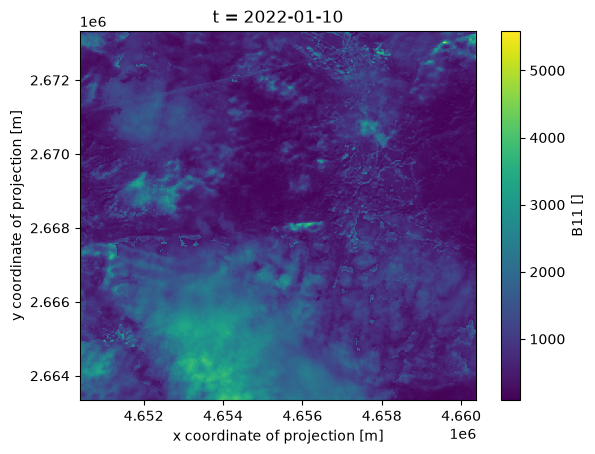

In [7]:
dataset.B11.isel(t=1).plot()